In [1]:
from qgravnet import QGravNetFactory

from utils.data import load_processed
from utils.evaluation import load_run
from utils.files import HLS4ML_OUT_PATH, PROJECT_ROOT, RESULTS_PATH

2025-12-04 11:44:33.820715: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-04 11:44:33.825170: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-04 11:44:33.862884: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-04 11:44:33.862904: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-04 11:44:33.862934: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

In [2]:
model_cfg, weights_path, history, datapath = load_run(RESULTS_PATH / 'train1')

D = load_processed(datapath)

# trained_model = QGravNetFactory(**model_cfg).create_keras_model(128, 4)
# trained_model.load_weights(weights_path)

from sklearn.model_selection import train_test_split
from hls4ml_gravnet.keras_models.qgravnet_minimal import QGravNetMinimalFactory
from utils.training import generate_train_data_random
from utils.evaluation import response_rmse


N_VERTICES = 128
N_FEATURES = 4
N_SAMPLES = 5000

x_rand, y_rand_energies, y_rand_pids = generate_train_data_random(N_VERTICES, N_FEATURES, N_SAMPLES)
x_rand_train, x_rand_test, y_rand_energies_train, y_rand_energies_test, y_rand_pids_train, y_rand_pids_test = (
    train_test_split(x_rand, y_rand_energies, y_rand_pids)
)

trained_model = QGravNetMinimalFactory(n_neighbours=model_cfg['n_neighbours']).create_keras_model(
    n_vertices=N_VERTICES, n_features=N_FEATURES
)
trained_model.compile(optimizer='adam', loss={'regression': response_rmse, 'classification': 'binary_crossentropy'})

trained_model.fit(
    x=D['X_hits_train'],
    y={
        'regression': D['y_energy_train'],
        'classification': D['y_pid_train'],
    },
)

test_energy_pred, test_pid_pred = trained_model.predict(D['X_hits_test'])


79/79 [==============================] - 1s 6ms/step


In [3]:
import hls4ml
from hls4ml_gravnet.hls4ml_extension.gravnet_core import HGravNetCore
from hls4ml_gravnet.hls4ml_extension.gravnet_core_parser import parse_gravnet_layer
from hls4ml_gravnet.hls4ml_extension.gravnet_core_template import GravNetCoreConfigTemplate, GravNetCoreFunctionTemplate

try:
    hls4ml.converters.register_keras_v2_layer_handler('GravNetCore', parse_gravnet_layer)
    hls4ml.model.layers.register_layer('GravNetCore', HGravNetCore)
    backend = hls4ml.backends.get_backend('Vitis')
    backend.register_template(GravNetCoreConfigTemplate)
    backend.register_template(GravNetCoreFunctionTemplate)
    backend.register_source(PROJECT_ROOT / 'hls4ml_gravnet' / 'hls' / 'nnet_gravnet_core.h')
except Exception:
    pass  # Already registered

In [12]:
hls_config = hls4ml.utils.config_from_keras_model(
    trained_model, granularity='name', default_precision='ap_fixed<32,16>', backend='Vitis', max_precision='ap_fixed<32,16>'
)

for layer in hls_config["LayerName"].keys():
    hls_config["LayerName"][layer]["Trace"] = True
    # for key in hls_config["LayerName"][layer]["Precision"].keys():
    #     hls_config["LayerName"][layer]["Precision"][key] = 'ap_fixed<32,16>'

print(hls_config)

hls_model = hls4ml.converters.convert_from_keras_model(
    trained_model, hls_config=hls_config, output_dir=str(HLS4ML_OUT_PATH / 'toy_calo'), backend='Vitis'
)
hls_model.compile()

/scratch/bozij/hls4ml-gravnet/.venv/lib/python3.11/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


{'Model': {'Precision': {'default': 'ap_fixed<32,16>', 'maximum': 'ap_fixed<32,16>'}, 'ReuseFactor': 1, 'Strategy': 'Latency', 'BramFactor': 1000000000, 'TraceOutput': False}, 'LayerName': {'input_1': {'Trace': True, 'Precision': {'result': 'auto'}}, 'input_bn': {'Trace': True, 'Precision': {'result': 'auto', 'scale': 'auto', 'bias': 'auto'}, 'ReuseFactor': 1}, 'dense_1': {'Trace': True, 'Precision': {'result': 'auto', 'weight': 'auto', 'bias': 'auto', 'accum': 'auto'}, 'ReuseFactor': 1}, 'dense_1_linear': {'Trace': True, 'Precision': {'result': 'auto', 'table': 'fixed<18,8,TRN,WRAP,0>'}, 'ReuseFactor': 1, 'TableSize': 1024}, 'global_exchange_min': {'Trace': True, 'Precision': {'result': 'auto', 'accum': 'auto'}, 'ReuseFactor': 1}, 'global_exchange_mean': {'Trace': True, 'Precision': {'result': 'auto', 'accum': 'auto'}, 'ReuseFactor': 1}, 'dense': {'Trace': True, 'Precision': {'result': 'auto', 'weight': 'auto', 'bias': 'auto', 'accum': 'auto'}, 'ReuseFactor': 1}, 'dense_linear': {'Tra

In [13]:
hls_test_energy_pred, hls_test_pid_pred = hls_model.predict(D['X_hits_test'])

Test Response RMSE: 0.3953
Test PID AUC: 0.8359


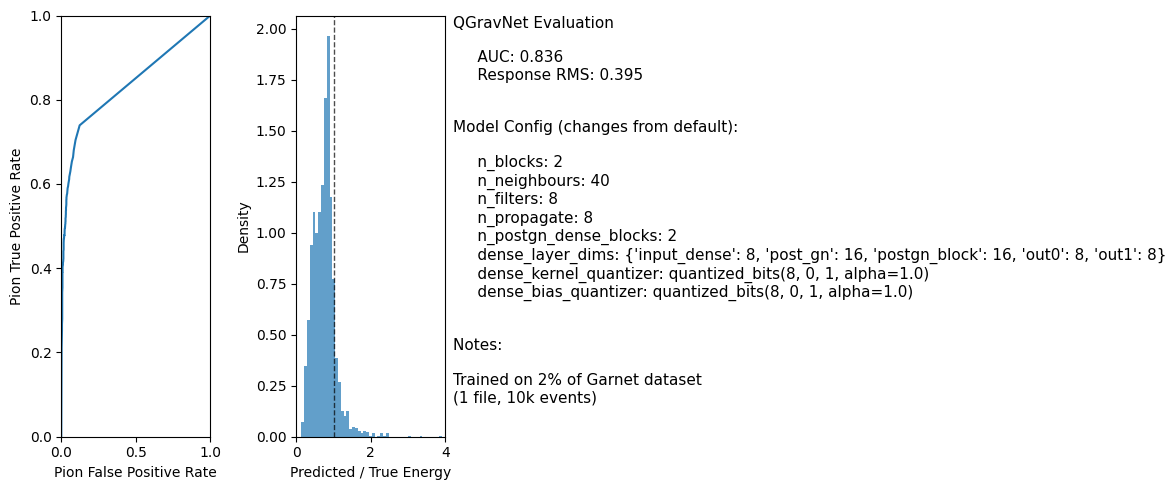

Test Response RMSE: 0.3819
Test PID AUC: 0.8356


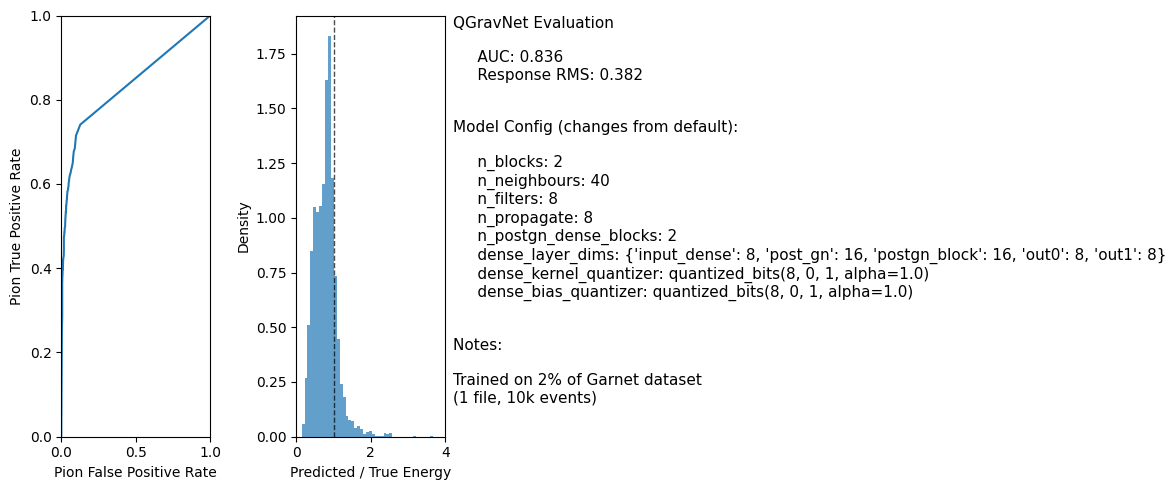

In [14]:
import numpy as np
from utils.evaluation import display_evaluation_results

# D = {
#     'X_hits_test': x_rand_test,
#     'y_energy_test': y_rand_energies_test,
#     'y_pid_test': y_rand_pids_test
# }
display_evaluation_results(test_energy_pred=test_energy_pred, test_pid_pred=test_pid_pred, D=D, model_cfg=model_cfg)
display_evaluation_results(test_energy_pred=hls_test_energy_pred, test_pid_pred=hls_test_pid_pred, D=D, model_cfg=model_cfg)

In [15]:
# hls_model.compile()
# hls_test_energy_pred, hls_test_pid_pred = hls_model.predict(D['X_hits_test'][:1])

In [16]:
from hls4ml.model.profiling import get_ymodel_keras

hls_pred, hls_trace = hls_model.trace(D['X_hits_test'])
keras_trace = get_ymodel_keras(trained_model, D['X_hits_test'])

Recompiling myproject with tracing


/scratch/bozij/hls4ml-gravnet/.venv/lib/python3.11/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


79/79 [==============================] - 1s 7ms/step
Done taking outputs for Keras model.


In [17]:
import numpy as np

# assert len(set(keras_trace.keys() - set(hls_trace.keys()))) == 0
# for key in hls_trace.keys():
#     if key in keras_trace:
#         print(key)
#         # print(f"{key}: {hls_trace[key] - keras_trace[key]}")
#         assert np.allclose(keras_trace[key], hls_trace[key], rtol=0, atol=1)

for key, value in keras_trace.items():
    print(f"{key}: {np.max(value)}, {np.min(value)}")

print()
for key, value in hls_trace.items():
    print(f"{key}: {np.max(value)}, {np.min(value)}")


q_dense: 21.70600128173828, -70.14511108398438
input_bn: 28.126684188842773, -3.0601325035095215
dense_1: 3.0601325035095215, -28.126684188842773
global_exchange_min: 3.0601325035095215, 0.005367946345359087
global_exchange_mean: 1.970643162727356, -0.7801375985145569
dense: -0.005367946345359087, -3.0601325035095215
global_exchange_global_stats_concat_1: 1.970643162727356, -3.0601325035095215
global_exchange_max: 28.126684188842773, -0.01793930120766163
global_exchange_global_stats_concat_2: 28.126684188842773, -3.0601325035095215
global_exchange_global_stats_reshape: 28.126684188842773, -3.0601325035095215
global_exchange_global_stats_upsample: 28.126684188842773, -3.0601325035095215
global_exchange_concat: 28.126684188842773, -3.0601325035095215
coords: 10.151447296142578, -24.134977340698242
feats: 30.45476722717285, -21.751739501953125
qgn_core: 16.794721603393555, -17.322668075561523
flatten: 16.794721603393555, -17.322668075561523
q_dense_sigmoid: 1.0, 3.438470969234356e-31
regr

Profiling weights (before optimization)
Weights for dense_1 are only zeros, ignoring.
Weights for dense are only zeros, ignoring.
[{'med': 1.4239004, 'q1': 1.4169678390026093, 'q3': 1.4362207055091858, 'whislo': 1.4123193, 'whishi': 1.457033, 'layer': 'input_bn', 'weight': 'input_bn/w'}, {'med': 0.010448416, 'q1': 0.006903467350639403, 'q3': 0.014595968183130026, 'whislo': 0.0053679463, 'whishi': 0.017939301, 'layer': 'input_bn', 'weight': 'input_bn/b'}, {'med': 1.0, 'q1': 1.0, 'q3': 1.0, 'whislo': 1.0, 'whishi': 1.0, 'layer': 'dense_1', 'weight': 'dense_1/w'}, {'med': 1.0, 'q1': 1.0, 'q3': 1.0, 'whislo': 1.0, 'whishi': 1.0, 'layer': 'dense', 'weight': 'dense/w'}, {'med': 0.19190583, 'q1': 0.07745901122689247, 'q3': 0.3499395474791527, 'whislo': 0.0011550616, 'whishi': 0.76620036, 'layer': 'coords', 'weight': 'coords/w'}, {'med': 0.017522274, 'q1': 0.010367984650656581, 'q3': 0.02208298910409212, 'whislo': 0.00088063604, 'whishi': 0.02378962, 'layer': 'coords', 'weight': 'coords/b'}, {

(<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 None,
 None)

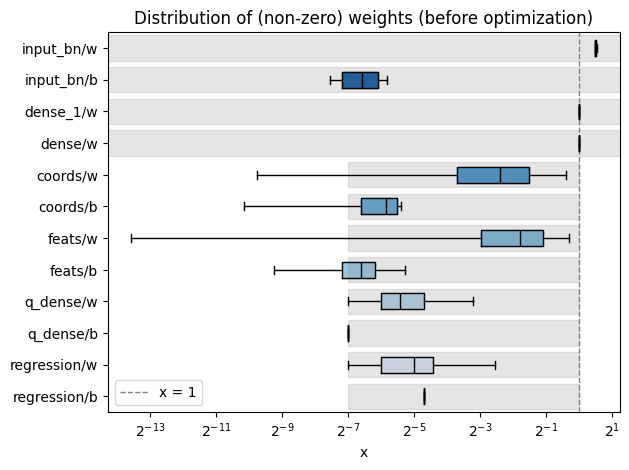

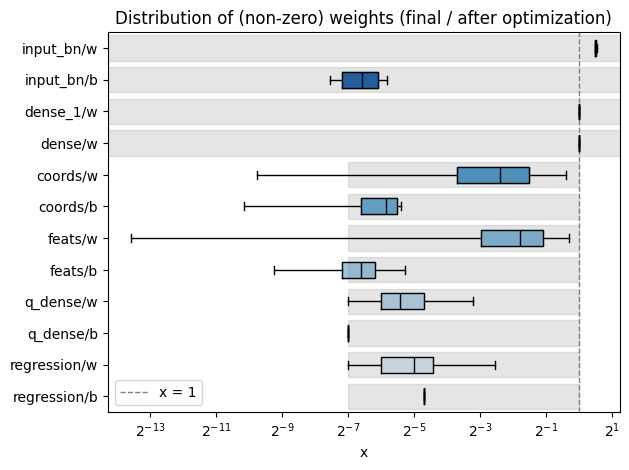

In [18]:
from hls4ml.model.profiling import numerical


numerical(model=trained_model, hls_model=hls_model)

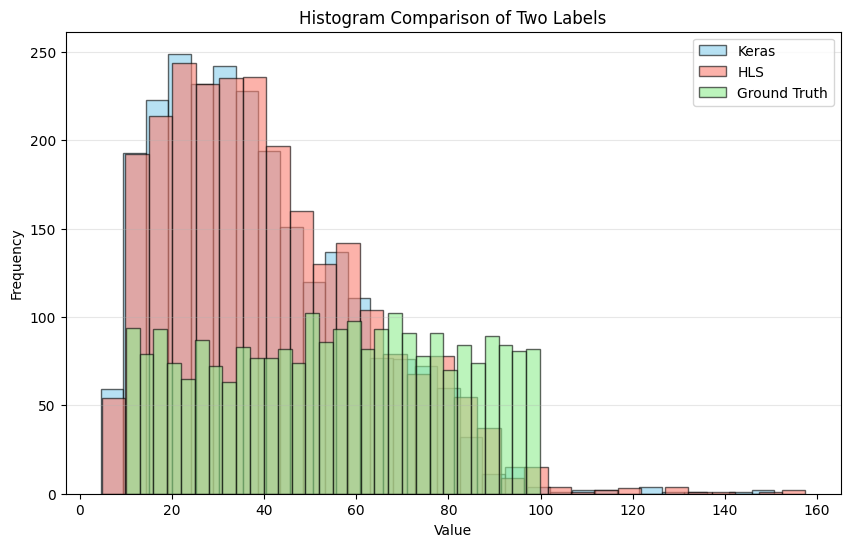

In [19]:
import matplotlib.pyplot as plt

# 2. Create the histogram plot
plt.figure(figsize=(10, 6))

# Plot the first label
plt.hist(
    test_energy_pred,
    bins=30,  # Number of bins
    alpha=0.6,  # Transparency for overlay
    label='Keras',
    color='skyblue',
    edgecolor='black'
)

# Plot the second label
plt.hist(
    hls_test_energy_pred,
    bins=30,
    alpha=0.6,
    label='HLS',
    color='salmon',
    edgecolor='black'
)

# Plot the second label
plt.hist(
    D['y_energy_test'],
    bins=30,
    alpha=0.6,
    label='Ground Truth',
    color='lightgreen',
    edgecolor='black'
)

# 3. Add titles and labels for clarity
plt.title('Histogram Comparison of Two Labels')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.show()

# # 4. Save the figure
# plt.savefig('dual_histogram.png')
# plt.close()